# Cómo usar `sizing`: el avión de 150 plazas del guion V4

Esta notebook es un tutorial del código. Dimensiona paso a paso el avión del
guion (`docs/Dimensionamiento_preliminar_aeronave_Raymer_V4.pdf`): un birreactor
de pasillo único, 150 pasajeros y 3 000 NM, con el método de Raymer
(*Aircraft Design: A Conceptual Approach*, 7.ª ed.).

Al terminar sabrás:

1. Describir un avión con las cuatro estructuras de entrada: `Mission`,
   `Aerodynamics`, `Design` y `Reference`.
2. Llamar a cada método por separado: pesos, carga alar, ala, fuselaje y colas.
3. Leer los resultados y usarlos para explorar hipótesis.
4. Ejecutar un caso completo de una vez y crear el tuyo.

| Carpeta | Qué usarás de ella |
|---|---|
| `core/` | Las entradas (`data.py`) y las constantes de unidades |
| `methods/` | `weight`, `aerodynamic`, `constraints` |
| `geometry/` | `wing`, `fuselage`, `tail` |

**Para ejecutarla:** `pip install -r requirements-dev.txt` desde la raíz del
repositorio y abre la notebook con Jupyter o VS Code.

In [1]:
import sys
from dataclasses import replace
from math import radians
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Los módulos se importan desde la raíz del repositorio
ROOT = Path.cwd() if (Path.cwd() / "main.py").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [2]:
# Estilo de las gráficas
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.figsize": (7.5, 3.6), "figure.dpi": 110, "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb", "axes.edgecolor": GRID, "axes.labelcolor": INK_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "lines.linewidth": 2, "font.size": 9.5, "legend.frameon": False,
})

## 1. La misión: `Mission`

Todo el código trabaja en SI, con las **masas en kg**. `core.constants` trae las
conversiones habituales para escribir los datos en las unidades en que suelen
venir: `NM` (millas náuticas → m), `KT` (nudos → m/s) y `HOUR` (h → s).

`Mission` recoge los requisitos. Solo `n_pax` es obligatorio; el resto tiene
valores por defecto (ver `core/README.md`). Las fracciones de los segmentos
cortos son las de la tabla 3.2 de Raymer. El guion junta descenso y aterrizaje
en un único 0.995, así que se quita el descenso con `descent=False`.

In [3]:
from core.constants import NM, KT, HOUR, G
from core.data import Mission

mission = Mission(
    n_pax=150, m_pax=100.0,          # pasajero con equipaje [kg]
    n_trip=6, m_trip=95.0,           # 2 pilotos + 4 TCP
    range=3000 * NM,                 # [m]
    mach=0.78,
    altitude=11_000,                 # [m]
    loiter=45 * 60,                  # espera [s]
    v_aprox=135 * KT,                # [m/s]
    F_takeoff=0.970, F_ascent=0.985, F_landing=0.995,
    descent=False,
    F_reserve=1.06,                  # 6 % de combustible atrapado y reserva
)
mission

Mission(n_pax=150, m_pax=100.0, n_trip=6, m_trip=95.0, range=5556000.0, mach=0.78, altitude=11000, loiter=2700, v_aprox=69.44994, F_takeoff=0.97, F_ascent=0.985, F_descent=0.99, descent=False, F_landing=0.995, F_reserve=1.06)

## 2. La aerodinámica: `Aerodynamics`

Las hipótesis aerodinámicas. Dos detalles de unidades que conviene recordar:
la flecha va **en radianes** y los consumos específicos en **s⁻¹**.

In [4]:
from core.data import Aerodynamics

aero = Aerodynamics(
    AR=9.5,                          # alargamiento
    swet_sref=6.0,                   # superficie mojada / de referencia
    k_ld=15.5,                       # (L/D)max = K_LD sqrt(A / (Swet/Sref))
    taper_ratio=0.24,
    sweep_c4=radians(25.0),          # flecha en c/4 [rad]
    c_cruise=0.5 / HOUR,             # consumo específico [1/s]
    c_loiter=0.4 / HOUR,
    cfe=0.0026,                      # fricción equivalente -> CD0 = Cfe Swet/Sref
)

`methods.aerodynamic` calcula lo que se deriva de estas hipótesis. Cada
función recibe las dataclasses y devuelve un número, así que se pueden consultar
sueltas:

In [5]:
from methods import aerodynamic

print(f"(L/D)max       {aerodynamic.ld_max(aero):.2f}")
print(f"(L/D)crucero   {aerodynamic.ld_cruise(aero):.2f}   (0.866 (L/D)max)")
print(f"Λ borde ataque {np.degrees(aerodynamic.sweep_le(aero)):.1f}°")
print(f"Oswald e       {aerodynamic.oswald(aero):.3f}   (Raymer 12.48, Λ_LE < 30°)")
print(f"CD0            {aerodynamic.cd0(aero):.4f}")
print(f"K              {aerodynamic.k(aero):.4f}")
print(f"V crucero      {aerodynamic.velocity_rel(mission):.1f} m/s")

(L/D)max       19.50
(L/D)crucero   16.89   (0.866 (L/D)max)
Λ borde ataque 28.0°
Oswald e       0.770   (Raymer 12.48, Λ_LE < 30°)
CD0            0.0156
K              0.0435
V crucero      230.2 m/s


## 3. Las decisiones de diseño: `Design`

`Design` agrupa lo que decide el proyectista: carga alar, empuje, cabina,
fuselaje y colas.

**La cabina** se describe con `Deck` (una cubierta) formada por `SeatingZone`
(una clase de asientos). De ella sale el fuselaje.

In [6]:
from geometry.fuselage import Deck, SeatingZone

cabin = Deck(
    name="main",
    zones=[
        SeatingZone("business", n_seats=12, seats_abreast=4, seat_pitch=0.97),   # 2-2
        SeatingZone("economy", n_seats=138, seats_abreast=6, seat_pitch=0.81),   # 3-3
    ],
    aisles=1,
    pax_per_lavatory=50,
)
print(f"{cabin.n_seats} asientos, {cabin.seats_abreast} por fila en la zona más ancha")

150 asientos, 6 por fila en la zona más ancha


**Las colas** se dimensionan con coeficientes de volumen (`TailCoefficients`) y
los mandos con cuerdas relativas (`ControlSurfaceRatios`). Sus valores por
defecto son los de Raymer para transporte a reacción; aquí se escriben
explícitamente para que se vea qué se puede cambiar.

In [7]:
from core.data import Design
from geometry.tail import TailCoefficients, ControlSurfaceRatios

design = Design(
    wing_loading=600.0,              # W0/S [kg/m2]
    cruise_wing_loading=550.0,       # W/S supuesta en crucero para la polar [kg/m2]
    thrust_to_weight=0.30,
    n_engines=2,
    max_mach=0.82,
    cl_max_landing=2.8,
    mlw_fraction=0.85,               # MLW / MTOW
    vref_factor=1.23,                # CS-25
    k_vs=1.0,                        # ala de flecha fija
    raymer_edition=7,                # tablas 3.1, 6.1 y 6.3 de la 7.ª edición
    decks=[cabin],
    fuselage={"diameter": 3.95, "nose": 4.0, "tailcone": 5.0},   # valores fijados [m]
    tail=TailCoefficients(c_ht=1.00, c_vt=0.09, arm_fraction=0.50),
    controls=ControlSurfaceRatios(elevator_chord=0.25, rudder_chord=0.32),
    tail_arm_length="statistical",   # brazo de cola sobre la longitud de la tabla 6.3
)

## 4. El peso al despegue: `weight.resolve`

`weight.resolve` itera la ecuación de pesos

$$
W_0 = \frac{W_\text{crew} + W_\text{payload}}{1 - \dfrac{W_f}{W_0} - \dfrac{W_e}{W_0}}
$$

y devuelve un `Result`. Sin `refined=True` usa el método de primer orden:
fracción en vacío de la tabla 3.1 y $L/D$ de crucero $= 0.866\,(L/D)_{\max}$.

In [8]:
from methods import weight

first = weight.resolve(mission, aero, design)

print(f"W0     {first.w0:>10,.0f} kg")
print(f"We     {first.w_empty:>10,.0f} kg   (We/W0 = {first.we_w0:.3f})")
print(f"Wf     {first.w_fuel:>10,.0f} kg   (Wf/W0 = {first.wf_w0:.3f})")
print(f"Carga  {weight.w_fixed(mission):>10,.0f} kg   (tripulación + pasajeros)")
print(f"Iteraciones: {len(first.history)}")

W0         71,940 kg
We         38,652 kg   (We/W0 = 0.537)
Wf         17,718 kg   (Wf/W0 = 0.246)
Carga      15,570 kg   (tripulación + pasajeros)
Iteraciones: 11


El guion llega a $W_0 \approx 72\,000$ kg. Los pasos intermedios también son
funciones públicas. Por ejemplo, la fracción de cada segmento, que se puede
convertir en combustible quemado:

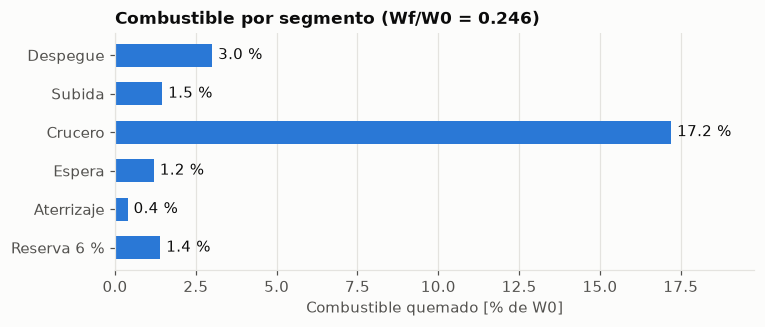

In [9]:
segments = {
    "Despegue": mission.F_takeoff,
    "Subida": mission.F_ascent,
    "Crucero": weight.F_cruise(mission, aero),       # Breguet de alcance
    "Espera": weight.F_loiter(mission, aero),        # Breguet de autonomía
    "Aterrizaje": mission.F_landing,
}
w, burned = 1.0, {}
for name, fraction in segments.items():
    burned[name] = w * (1 - fraction)
    w *= fraction
burned["Reserva 6 %"] = (mission.F_reserve - 1) * (1 - w)

fig, ax = plt.subplots(figsize=(7.5, 2.8))
names, values = list(burned)[::-1], [100 * v for v in burned.values()][::-1]
bars = ax.barh(names, values, color=BLUE, height=0.6)
ax.bar_label(bars, fmt="%.1f %%", padding=4, color=INK)
ax.set_xlabel("Combustible quemado [% de W0]")
ax.set_title(f"Combustible por segmento (Wf/W0 = {weight.F_fuel(mission, aero):.3f})")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, max(values) * 1.15)
plt.show()

## 5. La carga alar: `constraints`

`constraints` da los límites de la carga alar, referidos al despegue:

- `landing_wing_loading`: el máximo que permite la velocidad de aproximación.
- `cruise_wing_loading`: la del $C_L$ óptimo de crucero.
- `statistical_thrust_to_weight`: el $T/W$ de la tabla 5.3, como referencia.

Los límites se informan; la carga alar elegida sigue siendo `design.wing_loading`.

In [10]:
from methods import constraints

ws_landing = constraints.landing_wing_loading(mission, design)
ws_cruise = constraints.cruise_wing_loading(mission, aero)
print(f"W/S máx. aterrizaje   {ws_landing:.0f} kg/m2")
print(f"W/S óptima crucero    {ws_cruise:.0f} kg/m2")
print(f"W/S elegida           {design.wing_loading:.0f} kg/m2")
print(f"T/W estadístico       {constraints.statistical_thrust_to_weight(design):.3f}"
      f"  (elegido {design.thrust_to_weight})")

W/S máx. aterrizaje   656 kg/m2
W/S óptima crucero    356 kg/m2
W/S elegida           600 kg/m2
T/W estadístico       0.277  (elegido 0.3)


**Explorar una decisión.** Las dataclasses se copian con `dataclasses.replace`,
cambiando solo un campo. Así se barre la carga alar sin tocar `design`, y se ve
por qué el guion elige 600 kg/m²: el $W_0$ refinado (sección 7) baja al cargar
más el ala, hasta el límite del aterrizaje.

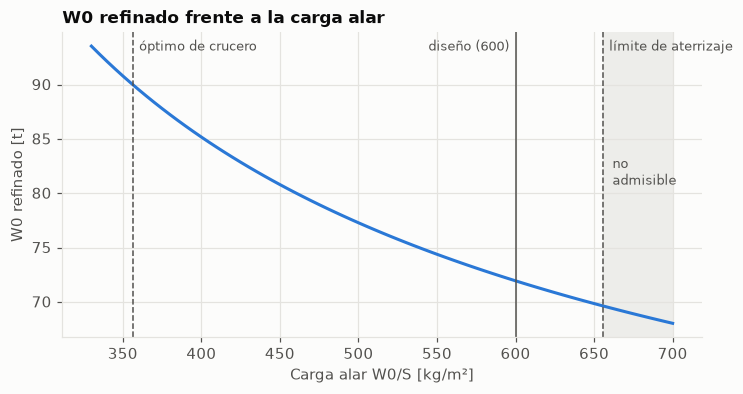

In [11]:
ws_range = np.linspace(330, 700, 75)
w0_ws = [weight.resolve(mission, aero, replace(design, wing_loading=ws), refined=True).w0
         for ws in ws_range]

fig, ax = plt.subplots()
ax.axvspan(ws_landing, ws_range[-1], color=GRID, alpha=0.6, lw=0)
ax.plot(ws_range, np.array(w0_ws) / 1e3, color=BLUE)
top = ax.get_ylim()[1]
for x, label, side in [(ws_cruise, "óptimo de crucero", 1), (design.wing_loading, "diseño (600)", -1),
                       (ws_landing, "límite de aterrizaje", 1)]:
    ax.axvline(x, color=INK_2, lw=1, ls="-" if x == design.wing_loading else "--")
    ax.annotate(label, (x, top), xytext=(4 * side, -12), textcoords="offset points",
                ha="left" if side > 0 else "right", color=INK_2, fontsize=8.5)
ax.text(ws_landing + 6, np.mean(ax.get_ylim()), "no\nadmisible", color=INK_2, fontsize=8.5)
ax.set_xlabel("Carga alar W0/S [kg/m²]")
ax.set_ylabel("W0 refinado [t]")
ax.set_title("W0 refinado frente a la carga alar")
plt.show()

## 6. El ala: `wing.wing_geometry`

Con $W_0$ y la carga alar, `wing_geometry` devuelve un `dict` con la planta
trapezoidal: `S`, `b`, `AR`, `c_root`, `c_tip` y `MAC`.

In [12]:
from geometry import wing

w1 = wing.wing_geometry(first.w0, aero, design)
for key, value in w1.items():
    print(f"{key:7}{value:8.2f}")

S        119.90
b         33.75
AR         9.50
c_root     5.73
c_tip      1.38
MAC        4.00


## 7. El dimensionamiento refinado

Con $A$, $W/S$, $T/W$ y $M_{\max}$ ya decididos, `refined=True` cambia tres cosas
respecto al primer orden:

| | Primer orden | Refinado |
|---|---|---|
| Fracción en vacío | Tabla 3.1 (solo $W_0$) | Tabla 6.1 ($W_0$, $A$, $T/W$, $W/S$, $M_{\max}$) |
| $L/D$ de crucero | $0.866\,(L/D)_{\max}$ | Polar parabólica en la carga alar de crucero (6.3.7) |
| Subida | 0.985 | $1.0065 - 0.0325\,M$ (6.3.6) |

Necesita un `Design`, porque la tabla 6.1 usa sus decisiones.

In [13]:
refined = weight.resolve(mission, aero, design, refined=True)

print(f"{'':10}{'primer orden':>14}{'refinado':>12}")
print(f"{'W0 [kg]':10}{first.w0:>14,.0f}{refined.w0:>12,.0f}")
print(f"{'We/W0':10}{first.we_w0:>14.3f}{refined.we_w0:>12.3f}")
print(f"{'Wf/W0':10}{first.wf_w0:>14.3f}{refined.wf_w0:>12.3f}")
print(f"\nL/D crucero con la polar: {aerodynamic.ld_cruise_refined(aero, mission, design):.2f}")

            primer orden    refinado
W0 [kg]           71,940      71,936
We/W0              0.537       0.553
Wf/W0              0.246       0.231

L/D crucero con la polar: 19.14


Los dos métodos acaban casi en el mismo $W_0$, pero por casualidad: el refinado
tiene más peso en vacío y menos combustible, y las diferencias se compensan.
`Result.history` guarda cada iteración como `(W0 de entrada, We/W0, W0 nuevo)`,
lo que permite ver cómo converge:

> El guion aplica además 0.866 sobre la $L/D$ de la polar y obtiene unos
> 79 800 kg; el código no lo hace porque la polar ya da la $L/D$ de crucero.
> El detalle está en `example/README.md`.

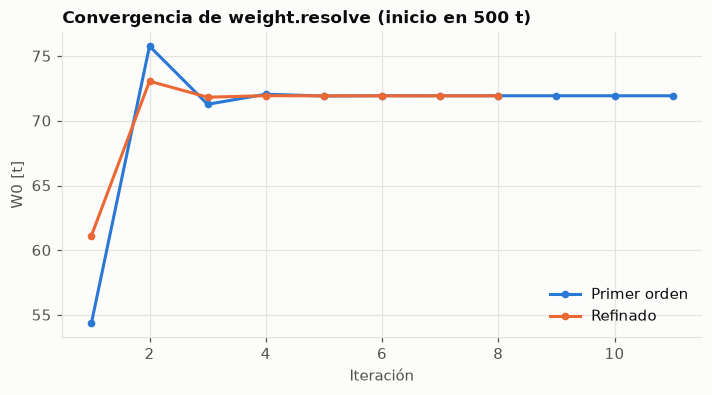

In [14]:
fig, ax = plt.subplots()
for result, color, label in [(first, BLUE, "Primer orden"), (refined, ORANGE, "Refinado")]:
    w0s = [new / 1e3 for _, _, new in result.history]
    ax.plot(range(1, len(w0s) + 1), w0s, color=color, marker="o", ms=4, label=label)
ax.set_xlabel("Iteración")
ax.set_ylabel("W0 [t]")
ax.set_title("Convergencia de weight.resolve (inicio en 500 t)")
ax.legend(loc="lower right")
plt.show()

El ala definitiva se calcula con el $W_0$ refinado. El `dict` de
`wing_geometry` tiene todo lo necesario para dibujar la planta:

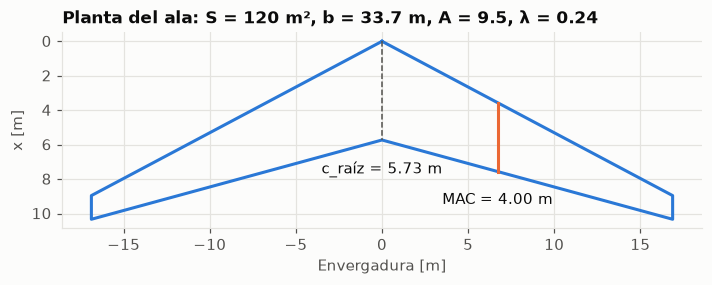

In [15]:
w2 = wing.wing_geometry(refined.w0, aero, design)

half, lam = w2["b"] / 2, aero.taper_ratio
x_tip = half * np.tan(aerodynamic.sweep_le(aero))      # borde de ataque en la punta
y_mac = half / 3 * (1 + 2 * lam) / (1 + lam)           # posición de la MAC
x_mac = y_mac / half * x_tip

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot([0, half, half, 0, -half, -half, 0],
        [0, x_tip, x_tip + w2["c_tip"], w2["c_root"], x_tip + w2["c_tip"], x_tip, 0], color=BLUE)
ax.plot([0, 0], [0, w2["c_root"]], color=INK_2, lw=1, ls="--")
ax.plot([y_mac, y_mac], [x_mac, x_mac + w2["MAC"]], color=ORANGE)
ax.annotate(f"c_raíz = {w2['c_root']:.2f} m", (0, w2["c_root"]), xytext=(0, -14),
            textcoords="offset points", ha="center", va="top", color=INK)
ax.annotate(f"MAC = {w2['MAC']:.2f} m", (y_mac, x_mac + w2["MAC"]), xytext=(0, -14),
            textcoords="offset points", ha="center", va="top", color=INK)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_xlabel("Envergadura [m]")
ax.set_ylabel("x [m]")
ax.set_title(f"Planta del ala: S = {w2['S']:.0f} m², b = {w2['b']:.1f} m, "
             f"A = {aero.AR}, λ = {lam}")
plt.show()

## 8. El fuselaje: `fuselage.fuselage_geometry`

El fuselaje sale de la cabina. `deck_length` desglosa la longitud de una
cubierta, y `fuselage_geometry` monta el fuselaje completo con las opciones de
`design.fuselage`. Con `w0` añade además la longitud estadística de la tabla 6.3.

In [16]:
from geometry import fuselage

for item, length in fuselage.deck_length(cabin).items():
    print(f"  {item:12}{length:6.2f} m")

  seating      21.54 m
  galleys       1.80 m
  lavatories    3.80 m
  exits         2.20 m
  stairs        0.00 m
  total        29.34 m


In [17]:
f = fuselage.fuselage_geometry(design.decks, w0=refined.w0,
                               edition=design.raymer_edition, **design.fuselage)
print(f"Longitud (cabina + morro + cola)  {f['length']:.2f} m")
print(f"Longitud estadística (tabla 6.3)  {f['statistical_length']:.2f} m")
print(f"Esbeltez L/D                      {f['fineness']:.2f}")

Longitud (cabina + morro + cola)  38.34 m
Longitud estadística (tabla 6.3)  38.67 m
Esbeltez L/D                      9.71


Las opciones de `design.fuselage` se comprueban: una clave mal escrita da un
error con la lista de claves válidas, en lugar de ignorarse.

In [18]:
try:
    fuselage.fuselage_geometry(design.decks, nose_angle=25)
except TypeError as error:
    print(error)

Unknown fuselage options ['nose_angle']; valid: ['crown', 'diameter', 'edition', 'hold', 'keel', 'nose', 'nose_lower_angle', 'nose_upper_angle', 'radome_height', 'structure_per_side', 'tailcone', 'tailcone_end_height', 'tailcone_lower_angle', 'tailcone_upper_angle']


Los estándares de cabina son campos de `Deck`. Por ejemplo, si se quiere un
lavabo cada 75 pasajeros en vez de cada 50:

In [19]:
fewer_lavs = replace(cabin, pax_per_lavatory=75)
print(f"Lavabos: {fuselage.deck_length(cabin)['lavatories']:.2f} m -> "
      f"{fuselage.deck_length(fewer_lavs)['lavatories']:.2f} m")

Lavabos: 3.80 m -> 2.85 m


## 9. Las colas: `tail.tail_geometry`

`tail_geometry` recibe el `dict` del ala, la longitud del fuselaje que fija el
brazo y los coeficientes. Como en el caso `tail_arm_length="statistical"`, el
brazo se mide sobre la longitud estadística.

In [20]:
from geometry import tail

arm_length = f["statistical_length"] if design.tail_arm_length == "statistical" else f["length"]
t = tail.tail_geometry(w2, arm_length, design.tail, design.controls)

print(f"Brazo de cola        {t['arm']:.2f} m")
print(f"Estabilizador horiz. {t['s_ht']:.1f} m2")
print(f"Estabilizador vert.  {t['s_vt']:.1f} m2")
for name, area in t["controls"].items():
    print(f"  {name:19}{area:.1f} m2")

Brazo de cola        19.33 m
Estabilizador horiz. 24.8 m2
Estabilizador vert.  18.8 m2
  ailerons           8.3 m2
  elevator           6.2 m2
  rudder             6.0 m2


Cambiar una hipótesis de la cola es cambiar `design.tail`. Un avión grande con
mandos de vuelo eléctricos puede trabajar con $c_{HT} \approx 0.65$:

In [21]:
relaxed = tail.tail_geometry(w2, arm_length, replace(design.tail, c_ht=0.65), design.controls)
print(f"S_HT: {t['s_ht']:.1f} m2 con c_HT = 1.00  ->  {relaxed['s_ht']:.1f} m2 con c_HT = 0.65")

S_HT: 24.8 m2 con c_HT = 1.00  ->  16.1 m2 con c_HT = 0.65


## 10. Todo de una vez: casos y `main.run`

Hasta aquí se han llamado los métodos uno a uno. Para el día a día, las entradas
se guardan en un **caso**: un archivo con una función `case()` que devuelve
`(mission, aero, design, reference)`. El de este avión es
`example/a320_guion_v4.py`, y tiene exactamente las entradas de esta notebook:

In [22]:
from example.a320_guion_v4 import case

case_mission, case_aero, case_design, reference = case()
assert (case_mission, case_aero, case_design) == (mission, aero, design)
print("Las entradas de la notebook y las del caso coinciden")

Las entradas de la notebook y las del caso coinciden


`main.run` encadena todos los pasos anteriores (pesos, restricciones, ala,
fuselaje y colas) y devuelve un `dict` con cada resultado. `main.report` lo
imprime junto al avión de referencia del caso (`Reference`). Es lo mismo que
`python main.py guion-v4` en la terminal.

In [23]:
from main import run, report

out = run("guion-v4")
print(sorted(out))
print(f"\nW0 = {out['weights'].w0:,.0f} kg, S = {out['wing']['S']:.1f} m2\n")
report(out)

['aero', 'design', 'fuselage', 'limits', 'reference', 'tail', 'weights', 'wing']

W0 = 71,936 kg, S = 119.9 m2

Case: refined   Raymer edition: 7   Reference: guion V4 (segment reference)
                              computed             actual     error

Weights
----------------------------------------------------------------------
  MTOW                          71,936 kg          78,000    -7.8 %
  OEW                           39,781 kg    
  MLW                           61,145 kg    
  Fuel (vs capacity)            16,584 kg          18,700   -11.3 %
  We/W0                          0.553       
  Wf/W0                          0.231       
  Iterations                         8       

Aerodynamics
----------------------------------------------------------------------
  Oswald e                       0.770       
  CD0                           0.0156       
  K                             0.0435       
  L/D cruise                     19.14       
  L/D loiter                 

## 11. Explorar: sensibilidad al alargamiento

Con `replace` y un bucle se estudia cualquier entrada. Aquí, $W_0$ frente al
alargamiento con los dos métodos. Las tendencias son opuestas:

- **Primer orden:** $A$ solo mejora $(L/D)_{\max} \propto \sqrt{A}$, así que más
  alargamiento siempre aligera.
- **Refinado:** la tabla 6.1 penaliza además el peso en vacío con $A^{0.398}$
  (un ala esbelta pesa más), y esa penalización domina.

Ninguno de los dos optimiza el ala; para eso habría que variar a la vez $A$,
$W/S$ y $S_\text{wet}/S_\text{ref}$.

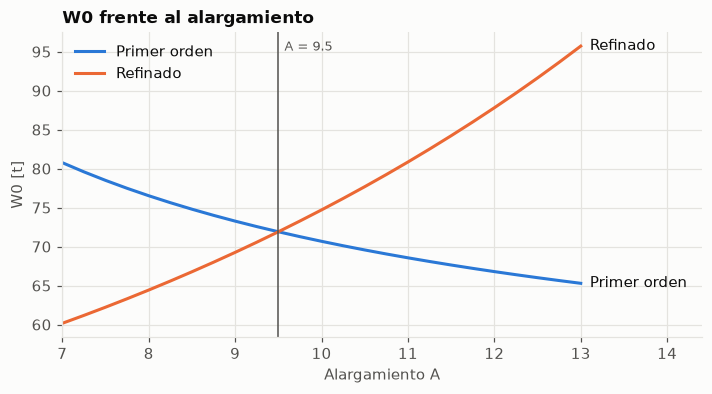

In [24]:
ar_range = np.linspace(7, 13, 25)
w0_first = [weight.resolve(mission, replace(aero, AR=ar), design).w0 / 1e3 for ar in ar_range]
w0_refined = [weight.resolve(mission, replace(aero, AR=ar), design, refined=True).w0 / 1e3
              for ar in ar_range]

fig, ax = plt.subplots()
for values, color, label in [(w0_first, BLUE, "Primer orden"), (w0_refined, ORANGE, "Refinado")]:
    ax.plot(ar_range, values, color=color, label=label)
    ax.annotate(label, (ar_range[-1], values[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK)
ax.axvline(aero.AR, color=INK_2, lw=1)
ax.annotate(f"A = {aero.AR}", (aero.AR, ax.get_ylim()[1]), xytext=(4, -12),
            textcoords="offset points", color=INK_2, fontsize=8.5)
ax.set_xlabel("Alargamiento A")
ax.set_ylabel("W0 [t]")
ax.set_title("W0 frente al alargamiento")
ax.set_xlim(ar_range[0], ar_range[-1] + 1.4)
ax.legend(loc="upper left")
plt.show()

## 12. Tu propio avión

1. Copia `example/a320_guion_v4.py` en `cases/mi_avion.py`.
2. Cambia `NAME` y las entradas de `case()`. Los campos de cada estructura
   están en `core/README.md`, y los de la cabina en `geometry/README.md`.
3. Ejecuta `python main.py mi-avion`, o en esta notebook:

```python
from cases.mi_avion import case
mission, aero, design, reference = case()
```

y vuelve a ejecutar las secciones que te interesen.